# Battery of specifications

Two parts, gathered here for readability. The verdicts themselves are produced upstream by the
audit notebook and frozen in the robustness table; this notebook recomputes no bootstrap at all.
It reads, cross-tabulates and draws.

**Part 1, specifications A and B.** A corrects the raw capacity by $P/R$, with precision and
recall counted over annotated objects; B corrects by $P_w/R_w$, weighted by capacity. B therefore
drops the homogeneity assumption {\bf H1}. The decision rule is the same in both cases: a unit is
flagged when its registry value falls outside the 99% credible interval. The **hard core** is the
intersection.

**Part 2, specification C, the conversion coefficient.** The coefficient is a pure multiplicative
factor: the corrected estimate and both its bounds scale as $K/c$, while the registry value does
not depend on $c$ at all. The verdict is therefore **monotone** in $c$ and flips at a single
threshold $c^\star$, available in closed form. That is what makes a numerical sweep unnecessary,
and it is worth noticing rather than sweeping anyway.

## 0. Config

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)


ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers
import style
import units
style.apply()

FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'specs'

BASELINE_COEF = 5.5
SPEC_LOW, SPEC_HIGH = 5.0, 6.0
STATUSES = ['below', 'within', 'above']

specs = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
departements = units.dissolve_units(
    gpd.read_file(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src' / paths.DEPARTEMENTS))

print(f"{len(specs)} unites de report")

93 unites de report


## 1. Specifications A and B

### 1.1 Concordance matrix

The two diagonal cells define the hard core. The two anti-diagonal cells are the substantive
result: if they are empty, no unit changes **direction** between the specifications, and the
disagreement is only ever about the boundary with `within`. A unit that flipped from
under-reported to over-reported would say something quite different about the method.

In [2]:
conc = pd.crosstab(specs['status_A'], specs['status_B']).reindex(
    index=STATUSES, columns=STATUSES, fill_value=0)
conc.index.name, conc.columns.name = 'Specification A', 'Specification B'
print(conc.to_string())

hc_below = conc.loc['below', 'below']
hc_above = conc.loc['above', 'above']
reversals = conc.loc['below', 'above'] + conc.loc['above', 'below']
print(f"\nhard core : {hc_below} below | {hc_above} above (controle negatif)")
print(f"renversements de sens A <-> B : {reversals}")

Specification B  below  within  above
Specification A                      
below               18       7      0
within               4      49      7
above                0       1      7

hard core : 18 below | 7 above (controle negatif)
renversements de sens A <-> B : 0


In [3]:
# tabular LaTeX pret a coller
rows = []
for a in STATUSES:
    cells_tex = []
    for b in STATUSES:
        v = conc.loc[a, b]
        bold = (a == b and a != 'within') or (a != b and 'within' not in (a, b))
        cells_tex.append(f"\\textbf{{{v}}}" if bold else str(v))
    rows.append(f"{a:<7} & " + " & ".join(cells_tex) + r" \\")

print("\n".join([
    r"\begin{tabular}{lccc}", r"\toprule",
    r" & \multicolumn{3}{c}{Specification B ($P_w/R_w$)} \\",
    r"\cmidrule(lr){2-4}",
    r"Specification A ($P/R$) & below & within & above \\", r"\midrule",
    *rows,
    r"\bottomrule", r"\end{tabular}",
]))

\begin{tabular}{lccc}
\toprule
 & \multicolumn{3}{c}{Specification B ($P_w/R_w$)} \\
\cmidrule(lr){2-4}
Specification A ($P/R$) & below & within & above \\
\midrule
below   & \textbf{18} & 7 & \textbf{0} \\
within  & 4 & 49 & 7 \\
above   & \textbf{0} & 1 & \textbf{7} \\
\bottomrule
\end{tabular}


### 1.2 Unit lists

Three sets per direction: the intersection, which is the hard core, the units flagged by A alone,
and those flagged by B alone. B is not nested inside A, so both `only` lists are non-empty. That
matters for the next section: two specifications that agreed by construction would make unanimity
meaningless.

In [4]:
def _sets(direction):
    a = set(specs.loc[specs['status_A'] == direction, 'dpt'])
    b = set(specs.loc[specs['status_B'] == direction, 'dpt'])
    return a, b, a & b


def _label(dpts):
    sub = specs[specs['dpt'].isin(dpts)].sort_values('dpt')
    return ', '.join(f"{r.nom} ({r.dpt})" for r in sub.itertuples())


membership = {}
for direction in ('below', 'above'):
    a, b, both = _sets(direction)
    membership[direction] = {'A \\cap B': both, 'A only': a - b, 'B only': b - a}
    print(f"=== {direction.upper()} ===")
    print(f"A: {len(a)} | B: {len(b)} | A n B: {len(both)}")
    for name, s in membership[direction].items():
        print(f"  {name:<9} ({len(s):>2}) : {_label(s) if s else '--'}")
    print()

=== BELOW ===
A: 25 | B: 22 | A n B: 18
  A \cap B  (18) : Bouches-du-Rhône (13), Calvados (14), Cantal (15), Corrèze (19), Creuse (23), Dordogne (24), Eure-et-Loir (28), Corse-du-Sud (2A), Haute-Corse (2B), Lozère (48), Meuse (55), Orne (61), Haute-Saône (70), Paris + petite couronne (75PC), Deux-Sèvres (79), Vienne (86), Vosges (88), Territoire de Belfort (90)
  A only    ( 7) : Indre (36), Loir-et-Cher (41), Lot-et-Garonne (47), Maine-et-Loire (49), Nièvre (58), Haute-Vienne (87), Val-d'Oise (95)
  B only    ( 4) : Alpes-de-Haute-Provence (04), Doubs (25), Bas-Rhin (67), Vendée (85)

=== ABOVE ===
A: 8 | B: 14 | A n B: 7
  A \cap B  ( 7) : Eure (27), Haute-Garonne (31), Indre-et-Loire (37), Manche (50), Meurthe-et-Moselle (54), Tarn (81), Yonne (89)
  A only    ( 1) : Hérault (34)
  B only    ( 7) : Gironde (33), Landes (40), Marne (51), Mayenne (53), Pyrénées-Orientales (66), Savoie (73), Var (83)



### 1.3 Table S2, unit by unit

One block per direction, three sub-blocks each, ordered hard core, A only, B only. The sub-blocks
stand in for indicator columns: position in the table carries membership, which reads better than
three columns of ticks.

In [5]:
def unit_table(direction):
    out = []
    for group, dpts in membership[direction].items():
        sub = specs[specs['dpt'].isin(dpts)].sort_values('dpt').copy()
        sub['group'] = group
        out.append(sub)
    t = pd.concat(out, ignore_index=True) if out else specs.iloc[:0].copy()
    t['registry_MWp'] = t['kWp_rte'] / 1000
    t['est_A_MWp'] = t['est_A'] / 1000
    t['est_B_MWp'] = t['est_B'] / 1000
    t['gap_A_MWp'] = t['est_A_MWp'] - t['registry_MWp']
    t['gap_B_MWp'] = t['est_B_MWp'] - t['registry_MWp']
    return t[['group', 'dpt', 'nom', 'registry_MWp', 'est_A_MWp', 'est_B_MWp',
              'gap_A_MWp', 'gap_B_MWp']]


table_s2 = pd.concat({d: unit_table(d) for d in ('below', 'above')}, names=['direction'])
table_s2 = table_s2.reset_index(level=0).reset_index(drop=True)
table_s2.to_csv(paths.TABLE_S2, index=False)

with pd.option_context('display.width', 200, 'display.max_rows', 80):
    print(table_s2.round(1).to_string(index=False))

hc = table_s2[(table_s2.direction == 'below') & (table_s2.group == 'A \\cap B')]
print(f"\nhard core below : {hc['gap_A_MWp'].sum():.0f} MWp (spec A)"
      f" | {hc['gap_B_MWp'].sum():.0f} MWp (spec B)")

direction    group  dpt                     nom  registry_MWp  est_A_MWp  est_B_MWp  gap_A_MWp  gap_B_MWp
    below A \cap B   13        Bouches-du-Rhône          77.3       89.7       89.9       12.4       12.6
    below A \cap B   14                Calvados          14.8       19.4       20.2        4.7        5.5
    below A \cap B   15                  Cantal          21.6       28.6       28.8        7.0        7.2
    below A \cap B   19                 Corrèze          17.6       29.3       27.2       11.7        9.6
    below A \cap B   23                  Creuse          11.4       17.8       17.6        6.4        6.3
    below A \cap B   24                Dordogne          37.6       52.6       51.6       15.0       14.0
    below A \cap B   28            Eure-et-Loir          12.0       22.9       22.8       10.9       10.8
    below A \cap B   2A            Corse-du-Sud           5.1       13.1       13.0        8.0        7.9
    below A \cap B   2B             Haute-Cors

## 2. Specification C: sensitivity to the conversion coefficient

### 2.1 The flipping threshold, in closed form

The corrected estimate and its credible bounds are proportional to $1/c$; the registry value is
constant in $c$. A unit is therefore `below` if and only if

$$\text{registre} < \frac{K_{\text{low}}}{c} \iff c < c^\star_{\text{below}}
= 5.5 \times \frac{\text{CI}_{99}^{\text{low}}}{\text{registre}},$$

and `above` if and only if $c > c^\star_{\text{above}} = 5.5 \times
\text{CI}_{99}^{\text{high}} / \text{registry}$.

The two directions are **mirror images**: a `below` unit loses its flag when the coefficient
*rises*, an `above` unit when it *falls*. The verdict cannot oscillate, so neither a flagging
frequency nor an average direction carries any information. Everything is in $c^\star$.

The next cell checks the closed form against the verdicts recomputed independently at the two
bounds upstream. It is an assertion rather than a printout on purpose: a closed form that quietly
disagreed with the recomputation would be worse than no closed form.

In [6]:
specs['c_star_below'] = BASELINE_COEF * specs['p_inst_ci99_low'] / specs['kWp_rte']
specs['c_star_above'] = BASELINE_COEF * specs['p_inst_ci99_high'] / specs['kWp_rte']


def status_at(c):
    return np.where(c < specs['c_star_below'], 'below',
                    np.where(c > specs['c_star_above'], 'above', 'within'))


for c, col in ((SPEC_LOW, 'status_C_50'), (BASELINE_COEF, 'status_A'), (SPEC_HIGH, 'status_C_60')):
    ok = (status_at(c) == specs[col]).all()
    assert ok, f"closed form disagrees with {col}"
    print(f"c = {c:.1f} -> reproduces {col}: OK")

print()
for c in (SPEC_LOW, BASELINE_COEF, SPEC_HIGH):
    s = pd.Series(status_at(c)).value_counts()
    print(f"c = {c:.1f} m2/kWp : {s.get('below', 0):>2} below | "
          f"{s.get('within', 0):>2} within | {s.get('above', 0):>2} above")

c = 5.0 -> reproduces status_C_50: OK
c = 5.5 -> reproduces status_A: OK
c = 6.0 -> reproduces status_C_60: OK

c = 5.0 m2/kWp : 37 below | 51 within |  5 above
c = 5.5 m2/kWp : 25 below | 60 within |  8 above
c = 6.0 m2/kWp : 15 below | 59 within | 19 above


In [7]:
# Robustness of the units flagged at the baseline coefficient
below_A = specs['status_A'] == 'below'
above_A = specs['status_A'] == 'above'

specs['survives_range'] = np.where(
    below_A, specs['c_star_below'] > SPEC_HIGH,
    np.where(above_A, specs['c_star_above'] < SPEC_LOW, False))

print(f"flagged below at {BASELINE_COEF}: {below_A.sum()}, of which "
      f"{(below_A & specs.survives_range).sum()} survive the whole range "
      f"[{SPEC_LOW}, {SPEC_HIGH}]")
print(f"flagged above at {BASELINE_COEF}: {above_A.sum()}, of which "
      f"{(above_A & specs.survives_range).sum()} survive")

# Units within at the baseline that acquire a flag somewhere in the range
within_A = specs['status_A'] == 'within'
gains_below = within_A & (specs['c_star_below'] > SPEC_LOW)
gains_above = within_A & (specs['c_star_above'] < SPEC_HIGH)
print(f"\nunits within at {BASELINE_COEF} that acquire a flag inside the range: "
      f"{gains_below.sum()} below and {gains_above.sum()} above")
print("-> not drawn on the map: the count is the informative part, and colouring "
      "them would fill the map without adding anything")

flagged below at 5.5: 25, of which 15 survive the whole range [5.0, 6.0]
flagged above at 5.5: 8, of which 5 survive

units within at 5.5 that acquire a flag inside the range: 12 below and 11 above
-> not drawn on the map: the count is the informative part, and colouring them would fill the map without adding anything


### 2.2 Map of the thresholds

Two panels, one per direction, because the meaning of the threshold is inverted between them.
Only units flagged at the baseline coefficient are coloured. Solid fill where the unit keeps its
flag across the whole range, hatched where it flips inside it. The overlaid number is $c^\star$.

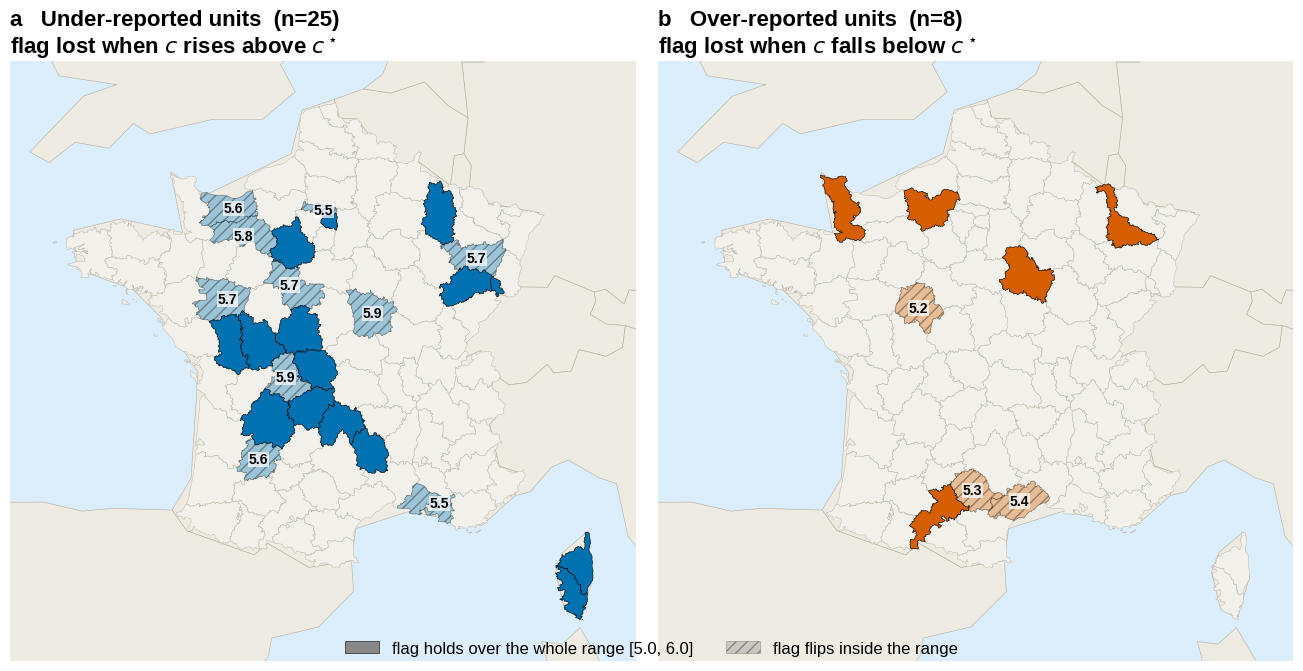

In [8]:
C_BELOW, C_ABOVE = style.OKABE_ITO['blue'], style.OKABE_ITO['vermillion']

# Font sizes
FONT_TITLE = 16
FONT_OTHER = 12
FONT_MAP_LABEL = 10

geo = departements.merge(
    specs,
    left_on='code',
    right_on='dpt',
    how='left'
)

if geo.crs is not None and geo.crs.to_epsg() != 4326:
    geo = geo.to_crs(4326)

panels = [
    (
        'a',
        'Under-reported units',
        'below',
        C_BELOW,
        'c_star_below',
        f"flag lost when $c$ rises above $c^\\star$"
    ),
    (
        'b',
        'Over-reported units',
        'above',
        C_ABOVE,
        'c_star_above',
        f"flag lost when $c$ falls below $c^\\star$"
    ),
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6.6),
    layout='constrained'
)

for ax, (
    letter,
    name,
    direction,
    color,
    col,
    subtitle
) in zip(axes, panels):

    helpers.add_basemap(
        ax,
        departements.total_bounds
    )

    geo.plot(
        ax=ax,
        facecolor='#f2f0ea',
        edgecolor='#b9b3a6',
        linewidth=0.3,
        zorder=1
    )

    flagged = geo[geo['status_A'] == direction]
    solid = flagged[flagged['survives_range']]
    fragile = flagged[~flagged['survives_range']]

    solid.plot(
        ax=ax,
        facecolor=color,
        edgecolor='black',
        linewidth=0.4,
        zorder=2
    )

    fragile.plot(
        ax=ax,
        facecolor=color,
        alpha=0.35,
        edgecolor='black',
        linewidth=0.4,
        hatch='///',
        zorder=2
    )

    # Only label c* values within [5.0, 6.0]
    labelled = flagged[
        flagged[col].between(5.0, 6.0, inclusive='both')
    ]

    for _, row in labelled.iterrows():
        pt = row.geometry.representative_point()

        ax.annotate(
            f"{row[col]:.1f}",
            (pt.x, pt.y),
            ha='center',
            va='center',
            fontsize=FONT_MAP_LABEL,
            fontweight='bold',
            color='black',
            zorder=5,
            bbox=dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.7,
                pad=0.5
            )
        )

    ax.set_title(
        f"{letter}   {name}  (n={len(flagged)})\n{subtitle}",
        fontweight='bold',
        fontsize=FONT_TITLE,
        loc='left'
    )

    helpers._hide_axis_chrome(ax)


from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(
            facecolor='#888888',
            edgecolor='black',
            lw=0.4,
            label=(
                f"flag holds over the whole range "
                f"[{SPEC_LOW}, {SPEC_HIGH}]"
            )
        ),
        Patch(
            facecolor='#888888',
            alpha=0.35,
            edgecolor='black',
            lw=0.4,
            hatch='///',
            label='flag flips inside the range'
        ),
    ],
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=FONT_OTHER
)

FIGS_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGS_DIR / f'{FIG_PREFIX}_conversion_thresholds.png',
    dpi=style.EXPORT_DPI,
    bbox_inches='tight'
)

fig.savefig(
    FIGS_DIR / f'{FIG_PREFIX}_conversion_thresholds.pdf',
    bbox_inches='tight'
)

plt.show()

In [9]:
# The fragile units in figures, for the manuscript text
frag = specs[(specs['status_A'].isin(['below', 'above'])) & (~specs['survives_range'])].copy()
frag['c_star'] = np.where(frag['status_A'] == 'below', frag['c_star_below'], frag['c_star_above'])
print("units whose flag flips inside the range:")
print(frag[['dpt', 'nom', 'status_A', 'c_star']].sort_values(['status_A', 'c_star'])
      .round(2).to_string(index=False))

units whose flag flips inside the range:
dpt              nom status_A  c_star
 37   Indre-et-Loire    above    5.20
 81             Tarn    above    5.34
 34          Hérault    above    5.36
 13 Bouches-du-Rhône    below    5.51
 95       Val-d'Oise    below    5.53
 47   Lot-et-Garonne    below    5.62
 14         Calvados    below    5.63
 88           Vosges    below    5.65
 41     Loir-et-Cher    below    5.67
 49   Maine-et-Loire    below    5.75
 61             Orne    below    5.78
 87     Haute-Vienne    below    5.87
 58           Nièvre    below    5.92


## 3. What this establishes

The hard core is the intersection of A and B, and **no unit changes direction** between them. The
disagreement is only about the boundary with `within`, which is the weakest kind of disagreement
two specifications can have.

B is not nested inside A. Each specification therefore carries information the other does not, and
unanimity between them is not cosmetic.

Specification C is not an independent specification but **a single monotone axis**. Its two bounds
are not two votes: counting them as such would count the same degree of freedom twice. That is why
it is treated as a sensitivity indicator rather than as a veto in the unanimity rule.

The threshold $c^\star$ is available in closed form and reproduces the independently recomputed
verdicts at both bounds exactly, which removes the need for any numerical sweep.